# Plant Disease Prediction System

This notebook trains a leaf image classifier using the existing `PlantVillage` dataset folder. It supports multiple image prediction, tells whether the plant looks healthy or infected, prints the disease name, shows prediction confidence/model accuracy, and gives cure or management advice.

**Important:** this notebook only reads images from `PlantVillage`. It does not move, delete, or modify the dataset.

In [ ]:
import sys
print("Python path:", sys.executable)

import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

Python path: c:\Users\Lenovo\OneDrive\Desktop\DL\plants_diseas_ditection\.venv\Scripts\python.exe


0

## 1. Imports and Settings

In [ ]:
from pathlib import Path
import json
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED) 
tf.random.set_seed(SEED)

DATASET_DIR = Path('PlantVillage')
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
MODEL_PATH = Path('plant_disease_model.keras')
CLASS_NAMES_PATH = Path('class_names.json')

print('TensorFlow version:', tf.__version__)
print('Dataset path:', DATASET_DIR.resolve())

TensorFlow version: 2.21.0
Dataset path: C:\Users\Lenovo\OneDrive\Desktop\DL\plants_diseas_ditection\PlantVillage


## 2. Scan Dataset Classes

The dataset has some classes directly inside `PlantVillage` and tomato classes inside `PlantVillage/Tomato`, so this scanner finds the real class folders recursively.

In [2]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.JPG', '.JPEG', '.PNG'}

def clean_class_name(path: Path) -> str:
    relative = path.relative_to(DATASET_DIR)
    parts = [part for part in relative.parts if part.lower() != 'tomato']
    return '__'.join(parts).replace(' ', '_')

def find_class_folders(dataset_dir: Path):
    class_folders = []
    for folder in sorted(dataset_dir.rglob('*')):
        if not folder.is_dir():
            continue
        has_images = any(file.suffix in IMAGE_EXTENSIONS for file in folder.iterdir() if file.is_file())
        if has_images:
            class_folders.append(folder)
    return class_folders

class_folders = find_class_folders(DATASET_DIR)
records = []
for class_folder in class_folders:
    class_name = clean_class_name(class_folder)
    for image_path in class_folder.iterdir():
        if image_path.is_file() and image_path.suffix in IMAGE_EXTENSIONS:
            records.append({'image_path': str(image_path), 'class_name': class_name})

df = pd.DataFrame(records)
if df.empty:
    raise ValueError('No images found. Please check that PlantVillage contains class folders with images.')

class_names = sorted(df['class_name'].unique())
class_to_index = {name: index for index, name in enumerate(class_names)}
df['label'] = df['class_name'].map(class_to_index)
df['is_infected'] = ~df['class_name'].str.lower().str.contains('healthy')

print('Total images:', len(df))
print('Total classes:', len(class_names))
display(df['class_name'].value_counts().rename_axis('class').reset_index(name='images'))

with open(CLASS_NAMES_PATH, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=2)

print('Saved class names to:', CLASS_NAMES_PATH.resolve())

Total images: 39851
Total classes: 41


,class,images
0,Ginger_Leaf_Dataset__Dehydrated,3372
1,Ginger_Leaf_Dataset__Leaf-blight,3264
2,Tomato__Tomato_YellowLeaf__Curl_Virus,3208
3,Ginger_Leaf_Dataset__Healthy,2198
4,Tomato_Bacterial_spot,2127
5,Ginger_Leaf_Dataset__Damage-Pest,2076
6,Tomato_Late_blight,1909
7,Tomato_Septoria_leaf_spot,1771
8,Tomato_Spider_mites_Two_spotted_spider_mite,1676
9,Tomato_healthy,1591


Saved class names to: C:\Users\Lenovo\OneDrive\Desktop\DL\plants_diseas_ditection\class_names.json


## 3. Create Train, Validation, and Test Data

In [3]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label']
)

print('Train images:', len(train_df))
print('Validation images:', len(val_df))
print('Test images:', len(test_df))

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(dataframe, shuffle=False):
    paths = dataframe['image_path'].astype(str).values
    labels = dataframe['label'].astype('int32').values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

Train images: 27895
Validation images: 5978
Test images: 5978


## 4. Show Sample Images

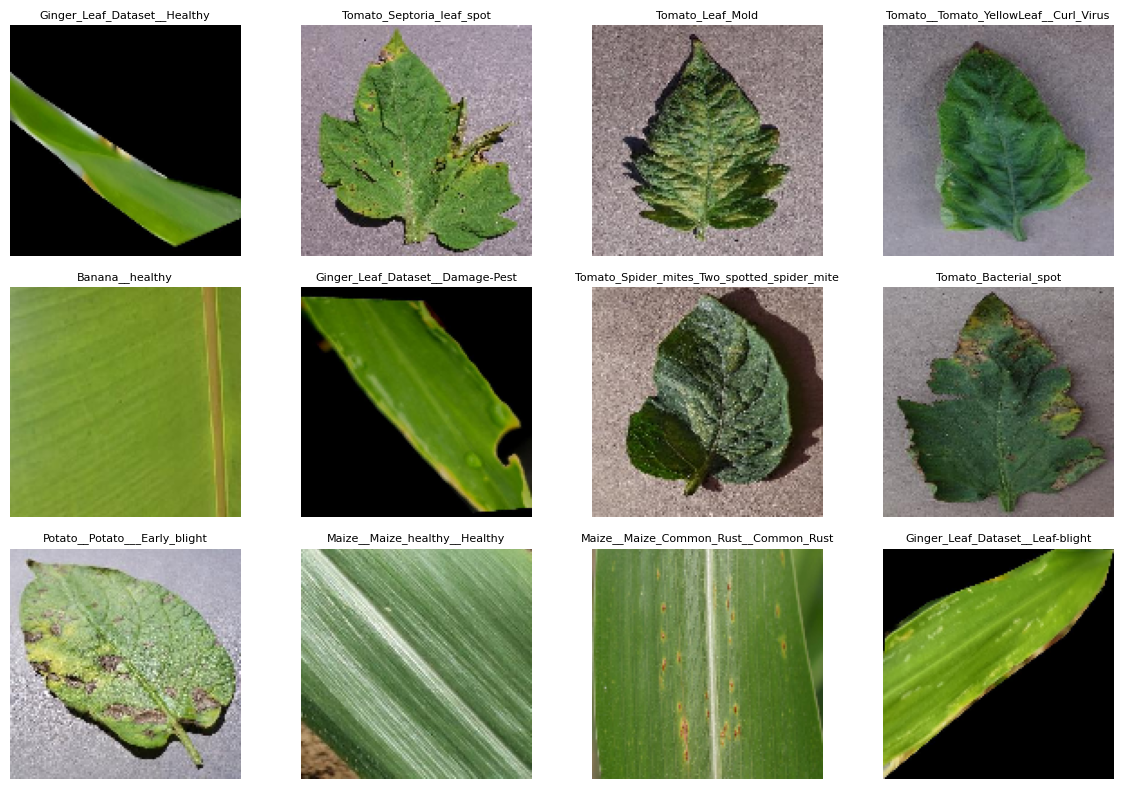

In [4]:
plt.figure(figsize=(12, 8))
sample_df = df.sample(min(12, len(df)), random_state=SEED).reset_index(drop=True)
for index, row in sample_df.iterrows():
    image = tf.keras.utils.load_img(row['image_path'], target_size=IMG_SIZE)
    plt.subplot(3, 4, index + 1)
    plt.imshow(image)
    plt.title(row['class_name'], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Build CNN Model

In [5]:
num_classes = len(class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.35),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 41)             │         5,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,521 (1.63 MB)

 Trainable params: 427,561 (1.63 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Train Model

In [6]:
callbacks = [
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

model.save(MODEL_PATH)
print('Saved trained model to:', MODEL_PATH.resolve())

Epoch 1/10
872/872 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.4250 - loss: 1.9122
Epoch 1: val_accuracy improved from None to 0.64386, saving model to plant_disease_model.keras

Epoch 1: finished saving model to plant_disease_model.keras
872/872 ━━━━━━━━━━━━━━━━━━━━ 794s 906ms/step - accuracy: 0.5241 - loss: 1.4855 - val_accuracy: 0.6439 - val_loss: 1.0417 - learning_rate: 0.0010
Epoch 2/10
872/872 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.6544 - loss: 0.9841
Epoch 2: val_accuracy did not improve from 0.64386
872/872 ━━━━━━━━━━━━━━━━━━━━ 761s 873ms/step - accuracy: 0.6772 - loss: 0.9195 - val_accuracy: 0.4848 - val_loss: 2.2146 - learning_rate: 0.0010
Epoch 3/10
872/872 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.7209 - loss: 0.7892
Epoch 3: val_accuracy improved from 0.64386 to 0.73971, saving model to plant_disease_model.keras

Epoch 3: finished saving model to plant_disease_model.keras
872/872 ━━━━━━━━━━━━━━━━━━━━ 634s 727ms/step - accuracy: 0.7343 - loss: 0.7431 -

## 7. Training Graph and Accuracy

,accuracy,loss,val_accuracy,val_loss,learning_rate
5,0.810504,0.521270,0.726832,0.796586,0.0010
6,0.826636,0.478222,0.831549,0.470860,0.0010
7,0.833626,0.456640,0.684008,1.185603,0.0010
8,0.843879,0.426729,0.638341,1.280164,0.0010
9,0.872020,0.346448,0.791736,0.725963,0.0003


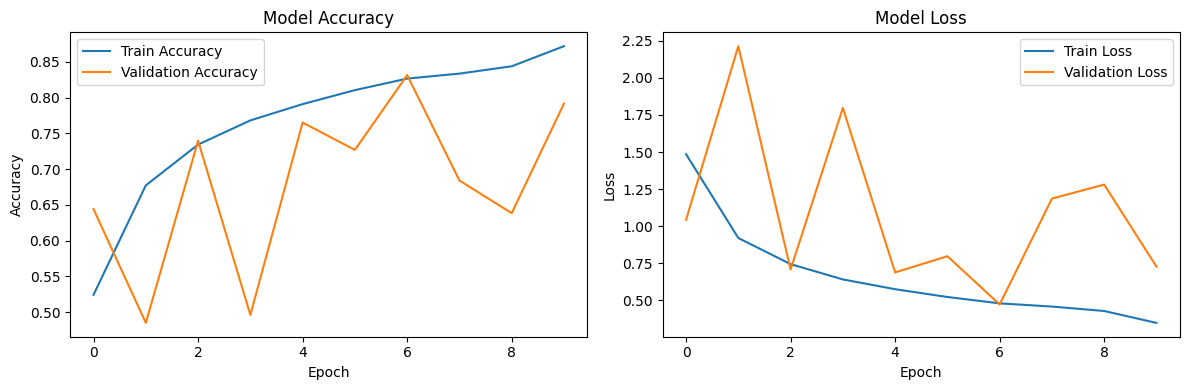

Test accuracy: 83.34%
Test loss: 0.4640


In [7]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')
print(f'Test loss: {test_loss:.4f}')

## 8. Classification Report

In [8]:
y_true = test_df['label'].astype('int32').values
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix shape:', cm.shape)

187/187 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step
                                             precision    recall  f1-score   support

                            Banana__cordana       0.93      0.95      0.94        60
                            Banana__healthy       0.98      0.70      0.82        60
                     Banana__pestalotiopsis       0.64      0.93      0.76        60
                           Banana__sigatoka       0.83      0.83      0.83        60
           Ginger_Leaf_Dataset__Damage-Pest       0.63      0.15      0.24       311
            Ginger_Leaf_Dataset__Dehydrated       0.58      0.96      0.72       506
               Ginger_Leaf_Dataset__Healthy       0.70      0.86      0.77       330
           Ginger_Leaf_Dataset__Leaf-blight       0.77      0.56      0.65       490
                Maize__Maize_Blight__Blight       0.84      0.86      0.85       172
      Maize__Maize_Common_Rust__Common_Rust       0.96      0.88      0.92       196
Maize__Maize_Gray_Le

## 9. Disease Cure and Solution Database

In [ ]:
DISEASE_SOLUTIONS = {
    'Pepper__bell___Bacterial_spot': 'Remove infected leaves, avoid overhead watering, use disease-free seed, rotate crops, and apply a copper-based bactericide as advised locally.',
    'Pepper__bell___healthy': 'The plant appears healthy. Continue balanced watering, sunlight, field sanitation, and regular monitoring.',
    'Potato___Early_blight': 'Remove infected leaves, rotate with non-host crops, avoid wet foliage, improve spacing, and use recommended fungicides such as chlorothalonil or mancozeb under local guidance.',
    'Potato___Late_blight': 'Destroy badly infected plants, avoid overhead irrigation, improve airflow, and apply protective fungicides quickly. Late blight spreads fast, so isolate affected plants.',
    'Potato___healthy': 'The plant appears healthy. Keep soil moisture steady, avoid leaf wetness, and scout weekly for early symptoms.',
    'Tomato_Bacterial_spot': 'Remove infected leaves, avoid splashing water, disinfect tools, rotate crops, and use copper-based sprays where recommended.',
    'Tomato_Early_blight': 'Prune lower infected leaves, mulch soil, avoid overhead watering, rotate crops, and apply recommended fungicide if disease pressure is high.',
    'Tomato_healthy': 'The plant appears healthy. Maintain proper watering, nutrition, airflow, and regular pest checks.',
    'Tomato_Late_blight': 'Remove infected plants or leaves quickly, avoid wet leaves, increase spacing, and use locally recommended fungicides. Do not compost infected material.',
    'Tomato_Leaf_Mold': 'Improve greenhouse or field ventilation, reduce humidity, avoid wetting leaves, remove infected foliage, and use labeled fungicide if needed.',
    'Tomato_Septoria_leaf_spot': 'Remove lower infected leaves, mulch to stop soil splash, avoid overhead watering, rotate crops, and use protective fungicide when required.',
    'Tomato_Spider_mites_Two_spotted_spider_mite': 'Spray leaves with water to reduce mites, remove heavily affected leaves, encourage beneficial insects, and use miticide or insecticidal soap if infestation is severe.',
    'Tomato__Target_Spot': 'Remove infected leaves, improve airflow, avoid overhead irrigation, rotate crops, and apply recommended fungicide during humid weather.',
    'Tomato__Tomato_mosaic_virus': 'Remove infected plants, disinfect hands and tools, control tobacco handling near plants, and grow resistant varieties. There is no direct cure for infected plants.',
    'Tomato__Tomato_YellowLeaf__Curl_Virus': 'Remove infected plants, control whiteflies with traps or recommended insecticides, remove weeds, and use resistant varieties. Viral infections cannot be cured once established.',
    'Banana__Cordana_leaf_spot': 'Remove and destroy infected leaves, maintain proper spacing for airflow, avoid overhead irrigation, ensure good drainage, and apply a recommended fungicide like mancozeb or copper-based spray as advised locally.',
    'Banana__Pestalotiopsis_leaf_spot': 'Prune and remove affected leaves, avoid excess moisture on foliage, improve field sanitation, use disease-free planting material, and apply appropriate fungicides such as carbendazim or mancozeb as per local guidance.',
    'Banana__Sigatoka_leaf_spot': 'Remove infected leaves regularly, maintain proper plant spacing, ensure good air circulation, apply balanced fertilization, and use fungicides like propiconazole or mancozeb in rotation as recommended locally.',
    'Ginger__Damage_Pest': 'Remove and destroy affected leaves, regularly monitor for pests, maintain field sanitation, use organic controls like neem oil, and apply recommended insecticides if infestation is severe as advised locally.',
    'Ginger__Dehydrated': 'Ensure proper and consistent irrigation, apply mulching to retain soil moisture, improve soil organic matter, avoid water stress during critical growth stages, and maintain proper drainage to support healthy plant growth.',
    'Ginger__Leaf_blight': 'Remove infected leaves promptly, avoid overhead watering, ensure proper spacing for airflow, use disease-free rhizomes, and apply fungicides like mancozeb or copper-based sprays as recommended locally.',
    'Maize__Blight': 'Remove and destroy infected leaves, practice crop rotation, ensure proper plant spacing for airflow, use resistant varieties if available, and apply fungicides like mancozeb or azoxystrobin as recommended locally.',
    'Maize__Common_Rust': 'Remove infected plant debris, plant resistant hybrids, maintain good field sanitation, monitor crop regularly, and apply fungicides such as propiconazole or mancozeb as advised locally.',
    'Maize__Gray_Leaf_Spot': 'Remove and destroy infected leaves, rotate crops with non-host plants, ensure adequate spacing for airflow, avoid prolonged leaf wetness, and apply fungicides like azoxystrobin or pyraclostrobin as recommended locally.',
    'Pigeon_pea__Leaf_Spot': 'Remove and destroy infected leaves, avoid overhead irrigation, maintain proper plant spacing for airflow, use disease-free seeds, and apply fungicides like mancozeb or copper-based sprays as recommended locally.','Pigeon_pea__Leaf_webber': 'Remove and destroy webbed and infested leaves, monitor regularly for larvae, encourage natural predators, use pheromone traps if available, and apply recommended insecticides like spinosad or neem-based sprays as advised locally.',
    'Pigeon_pea__Sterility_mosaic': 'Remove and destroy infected plants early, control vector mites, use resistant varieties if available, maintain field sanitation, and apply appropriate miticides as recommended locally.',
    'Turmeric__Dry_Leaf': 'Ensure proper and consistent irrigation, apply mulching to retain soil moisture, maintain soil organic matter, avoid water stress, and improve drainage to support healthy leaf growth.',
    'Turmeric__Leaf_Blotch': 'Remove and destroy infected leaves, avoid overhead watering, ensure proper spacing for airflow, use disease-free planting material, and apply fungicides like mancozeb or copper-based sprays as recommended locally.',
    'Banana__healthy': 'The plant appears healthy. Continue balanced watering, proper spacing, good drainage, regular monitoring, and maintain field sanitation.',
    'Chilli__healthy': 'The plant appears healthy. Continue balanced watering, adequate sunlight, proper fertilization, regular monitoring, and maintain field hygiene.',
    'Ginger__healthy': 'The plant appears healthy. Ensure consistent moisture, apply mulching, maintain soil health, and monitor regularly for early signs of pests or diseases.',
    'Maize__healthy': 'The plant appears healthy. Maintain proper irrigation, balanced fertilization, good spacing, and monitor regularly to prevent pests and diseases.',
    'Pigeon_pea__healthy': 'The plant appears healthy. Continue proper watering, maintain field sanitation, ensure good spacing, and monitor regularly for any issues.',
    'Turmeric__healthy': 'The plant appears healthy. Maintain adequate moisture, good soil health, proper spacing, and regular monitoring for sustained growth.',

}

def fallback_solution(class_name: str) -> str:
    if 'healthy' in class_name.lower():
        return 'The plant appears healthy. Continue good watering, nutrition, sanitation, and regular monitoring.'
    return 'Remove infected leaves, isolate badly affected plants, avoid overhead watering, improve airflow, and ask a local agriculture expert for the correct pesticide or fungicide.'

def get_solution(class_name: str) -> str:
    return DISEASE_SOLUTIONS.get(class_name, fallback_solution(class_name))

print('Disease solution records:', len(DISEASE_SOLUTIONS))

Disease solution records: 15


## 10. Predict One or Multiple Images

Use `predict_images([...])` with one or many image paths. The result includes infected/healthy status, disease name, prediction confidence, model test accuracy, and cure/solution.

In [10]:
def load_trained_model():
    if MODEL_PATH.exists():
        return keras.models.load_model(MODEL_PATH)
    return model

def preprocess_single_image(image_path):
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    image_array = tf.keras.utils.img_to_array(image) / 255.0
    return np.expand_dims(image_array, axis=0), image

def predict_images(image_paths, trained_model=None, show_images=True):
    if isinstance(image_paths, (str, Path)):
        image_paths = [image_paths]
    trained_model = trained_model or load_trained_model()
    results = []
    for image_path in image_paths:
        image_path = Path(image_path)
        image_batch, display_image = preprocess_single_image(image_path)
        probabilities = trained_model.predict(image_batch, verbose=0)[0]
        predicted_index = int(np.argmax(probabilities))
        predicted_class = class_names[predicted_index]
        confidence = float(probabilities[predicted_index])
        infected = 'healthy' not in predicted_class.lower()
        disease_name = 'Healthy leaf' if not infected else predicted_class.replace('___', ' - ').replace('__', ' ').replace('_', ' ')
        solution = get_solution(predicted_class)
        result = {
            'image': str(image_path),
            'status': 'Infected' if infected else 'Healthy',
            'disease_name': disease_name,
            'prediction_confidence': f'{confidence * 100:.2f}%',
            'model_test_accuracy': f'{test_accuracy * 100:.2f}%' if 'test_accuracy' in globals() else 'Run evaluation cell first',
            'solution': solution
        }
        results.append(result)
        print('\nImage:', result['image'])
        print('Status:', result['status'])
        print('Disease:', result['disease_name'])
        print('Prediction confidence:', result['prediction_confidence'])
        print('Model test accuracy:', result['model_test_accuracy'])
        print('Cure/Solution:', result['solution'])
        if show_images:
            plt.figure(figsize=(4, 4))
            plt.imshow(display_image)
            plt.title(f"{result['status']} | {result['prediction_confidence']}")
            plt.axis('off')
            plt.show()
    return pd.DataFrame(results)

# Example after training:
# predict_images(['PlantVillage/Potato___Early_blight/your_image.JPG'])

## 11. Farmer/User Upload Multiple Images

Run this cell in Jupyter Notebook. Click upload, select multiple leaf images, and then click `Predict uploaded images`.

In [11]:
import tempfile
from IPython.display import display

try:
    import ipywidgets as widgets

    uploader = widgets.FileUpload(
        accept='image/*',
        multiple=True,
        description='Upload leaves'
    )
    predict_button = widgets.Button(description='Predict uploaded images', button_style='success')
    output = widgets.Output()

    def save_uploaded_files(upload_widget):
        temp_dir = Path(tempfile.mkdtemp(prefix='leaf_uploads_'))
        saved_paths = []
        uploaded_values = upload_widget.value
        if isinstance(uploaded_values, dict):
            iterator = uploaded_values.values()
        else:
            iterator = uploaded_values
        for item in iterator:
            name = item.get('name', 'uploaded_leaf.jpg')
            content = item.get('content')
            if content is None:
                continue
            path = temp_dir / name
            path.write_bytes(bytes(content))
            saved_paths.append(path)
        return saved_paths

    def on_predict_clicked(_):
        with output:
            output.clear_output()
            saved_paths = save_uploaded_files(uploader)
            if not saved_paths:
                print('Please upload one or more leaf images first.')
                return
            display(predict_images(saved_paths, show_images=True))

    predict_button.on_click(on_predict_clicked)
    display(uploader, predict_button, output)
except ImportError:
    print('ipywidgets is not installed. Use predict_images([path1, path2, ...]) instead, or install ipywidgets.')

ipywidgets is not installed. Use predict_images([path1, path2, ...]) instead, or install ipywidgets.


## 12. Save a Simple Prediction Report CSV

In [12]:
# Optional example:
# report = predict_images(['path/to/leaf1.jpg', 'path/to/leaf2.jpg'], show_images=False)
# report.to_csv('plant_disease_predictions.csv', index=False)
# display(report)